In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Conv2DTranspose

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


In [2]:
(x_tr, _), (x_te, _) = tf.keras.datasets.mnist.load_data()

x_tr = x_tr.astype('float32') / 255.0
x_te = x_te.astype('float32') / 255.0

x_tr = x_tr[..., np.newaxis]
x_te = x_te[..., np.newaxis]

print("Train:", x_tr.shape)
print("Test :", x_te.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Train: (60000, 28, 28, 1)
Test : (10000, 28, 28, 1)


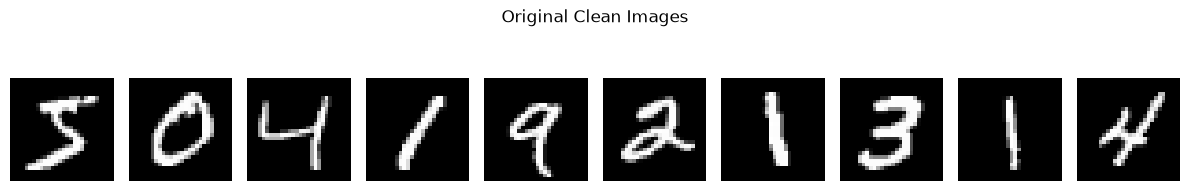

In [3]:
plt.figure(figsize=(12, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_tr[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.suptitle('Original Clean Images', y=1.02)
plt.tight_layout()
plt.show()

In [4]:
noise = 0.5                                        # ← change this (0.1 to 0.9)

x_tr_n = x_tr + noise * np.random.normal(size=x_tr.shape)
x_te_n = x_te + noise * np.random.normal(size=x_te.shape)

x_tr_n = np.clip(x_tr_n, 0.0, 1.0)
x_te_n = np.clip(x_te_n, 0.0, 1.0)

print("Noisy Train:", x_tr_n.shape)

Noisy Train: (60000, 28, 28, 1)


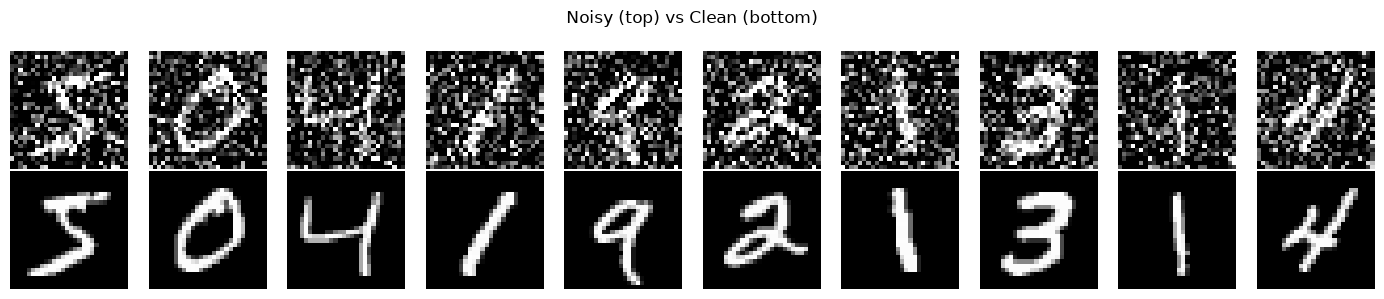

In [5]:
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for i in range(10):
    axes[0, i].imshow(x_tr_n[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(x_tr[i].squeeze(),   cmap='gray')
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('Noisy',  fontsize=11)
axes[1, 0].set_ylabel('Clean',  fontsize=11)
plt.suptitle('Noisy (top) vs Clean (bottom)', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
inp = Input(shape=(28, 28, 1))

# ── Encoder ───────────────────────────────────────────────────────────────
x = Conv2D(32, 3, activation='relu', padding='same')(inp)
x = MaxPooling2D(2, padding='same')(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
enc_out = MaxPooling2D(2, padding='same')(x)           # (7, 7, 64)

# ── Decoder ───────────────────────────────────────────────────────────────
x = Conv2DTranspose(64, 3, strides=2, activation='relu', padding='same')(enc_out)
x = Conv2DTranspose(32, 3, strides=2, activation='relu', padding='same')(x)     
dec_out = Conv2D(1, 3, activation='sigmoid', padding='same')(x)                   

ae = Model(inp, dec_out)
ae.compile(optimizer='adam', loss='binary_crossentropy')
ae.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
encoder = Model(inp, enc_out)
print("Encoder output shape:", encoder.output_shape)
print("Compressed from 28×28×1 =", 28*28, "→ 7×7×64 =", 7*7*64, "values")
print(f"Compression ratio: {28*28 / (7*7*64):.4f}")

Encoder output shape: (None, 7, 7, 64)
Compressed from 28×28×1 = 784 → 7×7×64 = 3136 values
Compression ratio: 0.2500


In [8]:
hist = ae.fit(
    x_tr_n, x_tr,
    epochs=20,                               # ← change this (10 to 50)
    batch_size=128,                          # ← change this (64 to 256)
    validation_data=(x_te_n, x_te),
    shuffle=True
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 77s 161ms/step - loss: 0.1768 - val_loss: 0.1158
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 55s 117ms/step - loss: 0.1123 - val_loss: 0.1085
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 53s 113ms/step - loss: 0.1070 - val_loss: 0.1052
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 53s 113ms/step - loss: 0.1042 - val_loss: 0.1023
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 51s 109ms/step - loss: 0.1024 - val_loss: 0.1010
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 51s 110ms/step - loss: 0.1011 - val_loss: 0.1000
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 56s 119ms/step - loss: 0.1001 - val_loss: 0.0989
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 49s 105ms/step - loss: 0.0993 - val_loss: 0.0985
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 60s 128ms/step - loss: 0.0986 - val_loss: 0.0978
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 52s 111ms/step - loss: 0.0982 - val_loss: 0.0972
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 55s 116ms/step - loss: 0.0977 - val_loss: 0.0971
Epoch 12/20
469/469

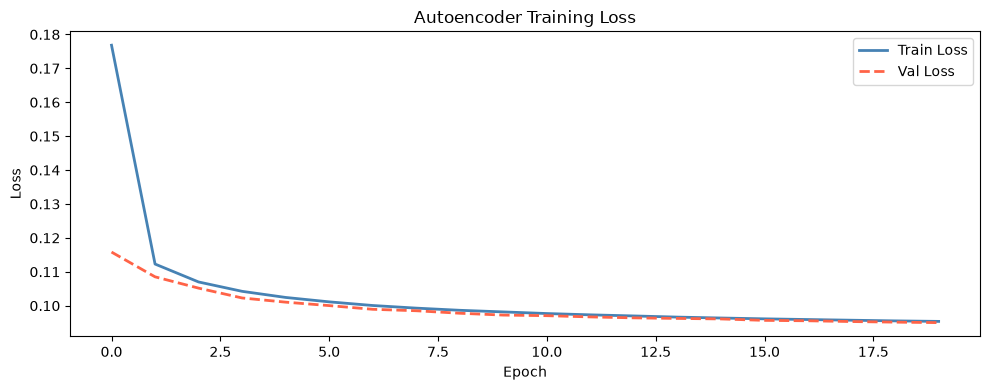

In [9]:
plt.figure(figsize=(10, 4))
plt.plot(hist.history['loss'],     label='Train Loss', color='steelblue', lw=2)
plt.plot(hist.history['val_loss'], label='Val Loss',   color='tomato',    lw=2, ls='--')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


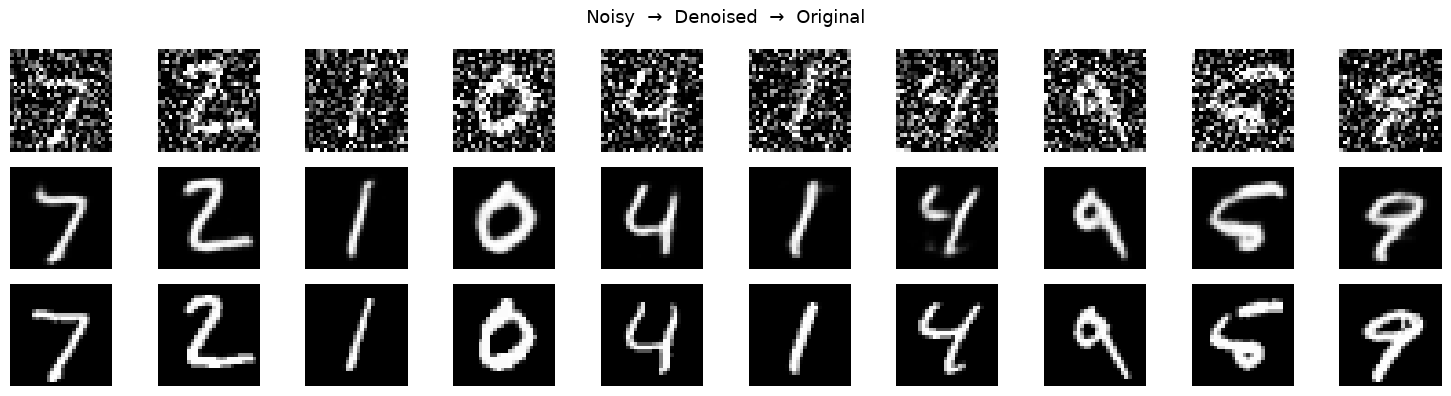

In [10]:
recon = ae.predict(x_te_n[:10])

fig, axes = plt.subplots(3, 10, figsize=(15, 4))
titles = ['Noisy', 'Denoised', 'Original']
rows   = [x_te_n[:10], recon, x_te[:10]]
colors = ['Reds', 'Greens', 'Blues']

for r, (data, title, cmap) in enumerate(zip(rows, titles, colors)):
    for c in range(10):
        axes[r, c].imshow(data[c].squeeze(), cmap='gray')
        axes[r, c].axis('off')
    axes[r, 0].set_ylabel(title, fontsize=11, fontweight='bold')

plt.suptitle('Noisy  →  Denoised  →  Original', fontsize=13)
plt.tight_layout()
plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


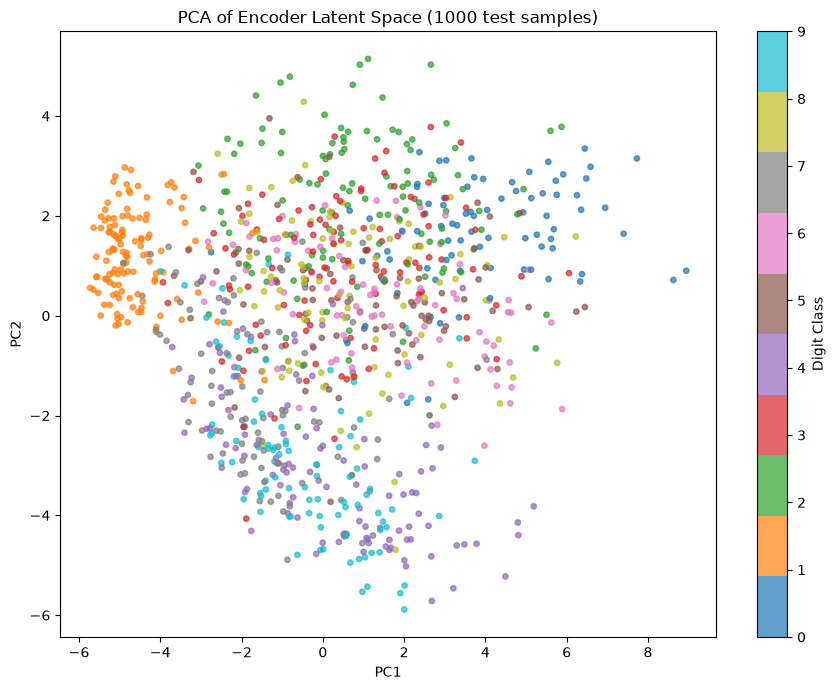

In [13]:
(_, y_te_labels), = [(None, y) for _, y in [tf.keras.datasets.mnist.load_data()[1]]]

enc_repr = encoder.predict(x_te_n[:1000])
enc_flat = enc_repr.reshape(1000, -1)

from sklearn.decomposition import PCA
pca  = PCA(n_components=2)
proj = pca.fit_transform(enc_flat)

plt.figure(figsize=(9, 7))
sc = plt.scatter(proj[:, 0], proj[:, 1],
                 c=y_te_labels[:1000], cmap='tab10',
                 alpha=0.7, s=15)
plt.colorbar(sc, label='Digit Class')
plt.title('PCA of Encoder Latent Space (1000 test samples)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.tight_layout()
plt.show()

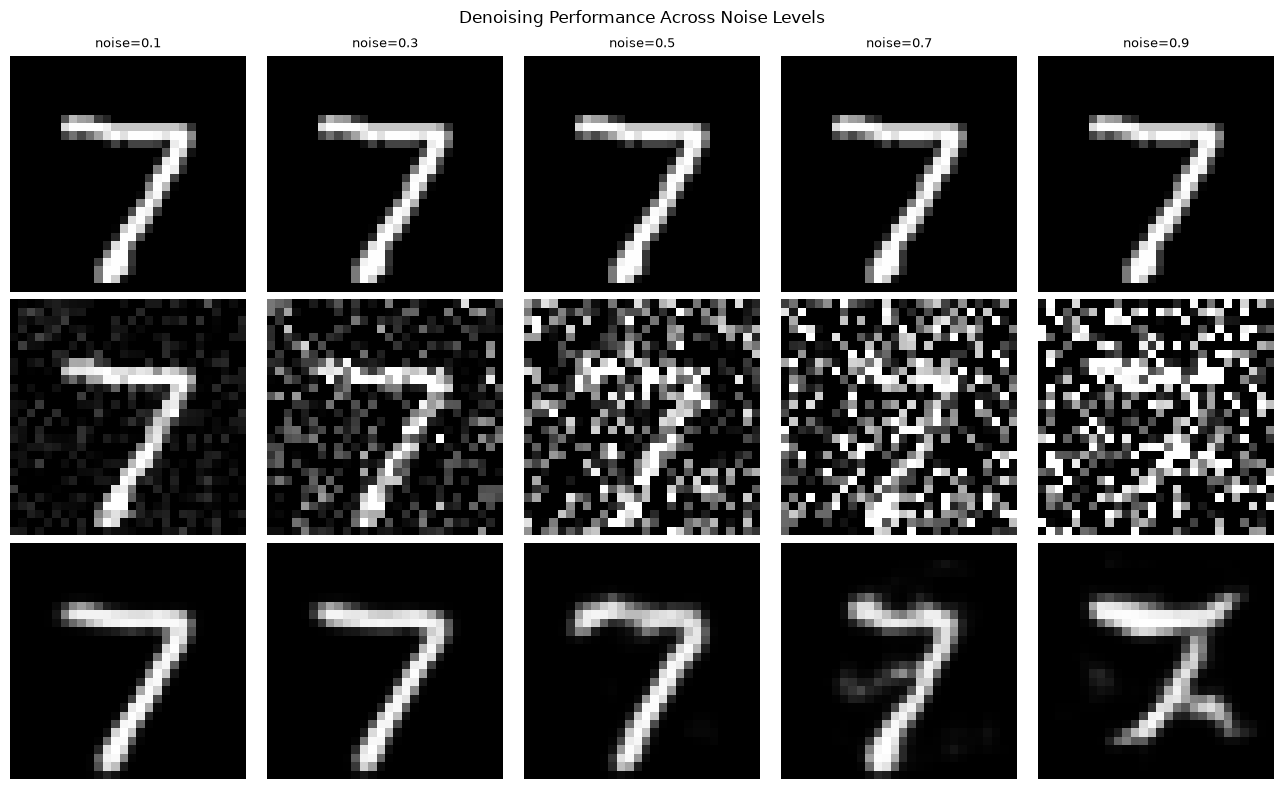

In [14]:
fig, axes = plt.subplots(3, 5, figsize=(13, 8))
noise_levels = [0.1, 0.3, 0.5, 0.7, 0.9]

for col, nf in enumerate(noise_levels):
    noisy  = np.clip(x_te[:5] + nf * np.random.normal(size=x_te[:5].shape), 0, 1)
    recon_ = ae.predict(noisy, verbose=0)

    axes[0, col].imshow(x_te[0].squeeze(),   cmap='gray')
    axes[1, col].imshow(noisy[0].squeeze(),   cmap='gray')
    axes[2, col].imshow(recon_[0].squeeze(),  cmap='gray')
    axes[0, col].set_title(f'noise={nf}', fontsize=9)
    for r in range(3):
        axes[r, col].axis('off')

axes[0, 0].set_ylabel('Original',  fontsize=10, fontweight='bold')
axes[1, 0].set_ylabel('Noisy',     fontsize=10, fontweight='bold')
axes[2, 0].set_ylabel('Denoised',  fontsize=10, fontweight='bold')
plt.suptitle('Denoising Performance Across Noise Levels', fontsize=12)
plt.tight_layout()
plt.show()

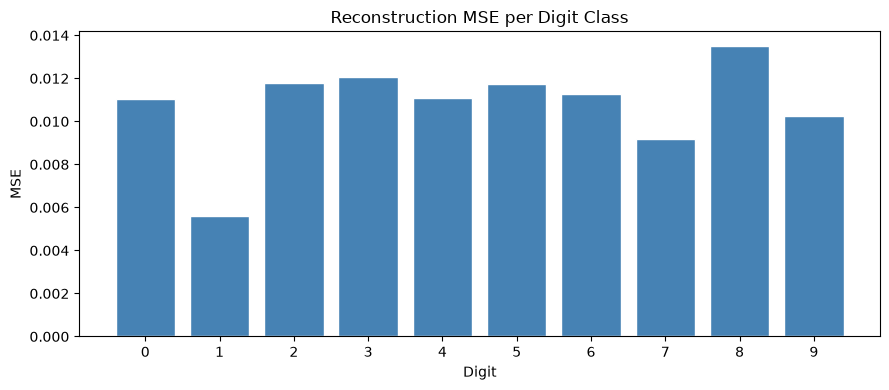

MSE per class:
  Digit 0: 0.011042
  Digit 1: 0.005581
  Digit 2: 0.011787
  Digit 3: 0.012077
  Digit 4: 0.011075
  Digit 5: 0.011758
  Digit 6: 0.011294
  Digit 7: 0.009176
  Digit 8: 0.013511
  Digit 9: 0.010263


In [15]:
recon_all = ae.predict(x_te_n, verbose=0)
(_, y_lbl), = [(None, y) for _, y in [tf.keras.datasets.mnist.load_data()[1]]]

mse_per_class = {}
for d in range(10):
    idx = np.where(y_lbl == d)[0]
    mse = np.mean((x_te[idx] - recon_all[idx]) ** 2)
    mse_per_class[d] = round(float(mse), 6)

plt.figure(figsize=(9, 4))
plt.bar(mse_per_class.keys(), mse_per_class.values(),
        color='steelblue', edgecolor='white')
plt.title('Reconstruction MSE per Digit Class')
plt.xlabel('Digit'); plt.ylabel('MSE')
plt.xticks(range(10))
plt.tight_layout()
plt.show()

print("MSE per class:")
for k, v in mse_per_class.items():
    print(f"  Digit {k}: {v}")

In [16]:
final_loss     = hist.history['loss'][-1]
final_val_loss = hist.history['val_loss'][-1]
overall_mse    = np.mean((x_te - recon_all) ** 2)

import pandas as pd
summary = pd.DataFrame({
    'Metric' : ['Final Train Loss', 'Final Val Loss', 'Overall Reconstruction MSE'],
    'Value'  : [round(final_loss,4), round(final_val_loss,4), round(float(overall_mse),6)]
})
print(summary.to_string(index=False))

                    Metric    Value
          Final Train Loss 0.095400
            Final Val Loss 0.095000
Overall Reconstruction MSE 0.010665
